### Libraries

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import StackingClassifier
import warnings
warnings.filterwarnings('ignore')


### Loading train data

In [16]:
df = pd.read_csv("train.csv", index_col=0).drop(["Surname", "CustomerId"], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


### Adding new features

In [17]:
def featuer_engineering(data):
    # Age
    data["Age_order_by_quantity"] = pd.qcut(data["Age"], q = 5)
    data["Age_groups"] = pd.cut(data["Age"], bins = 3)
    data["Gender_IsActive"] = df["Gender"]
    data["Log(AGE)"] = (np.log(data["Age"]))
    data["Age dagree = 4"] = data["Age"] ** 4 

    # Balance
    data["Balance_group"] = pd.cut(data["Balance"] , bins=5)
    one = OneHotEncoder()
    encoded = one.fit_transform(df[['NumOfProducts']])
    df_encoded = pd.DataFrame(encoded.toarray(), columns=one.get_feature_names_out(['NumOfProducts']))

    data = pd.concat([data, df_encoded], axis=1)

    # Number of Products
    data["IsActive + Products"] = data["NumOfProducts"] * (5 * data["IsActiveMember"])

In [18]:
def encoder(data):
    one = OneHotEncoder()
    encoded = one.fit_transform(df[['NumOfProducts']])
    df_encoded = pd.DataFrame(encoded.toarray(), columns=one.get_feature_names_out(['NumOfProducts']))

    data = pd.concat([data, df_encoded], axis=1)
    return data

In [19]:
WoE_values = {}

def WoE(data, col, target):
    event = data[target].sum()
    non_event = len(data) - event

    grouped = data.groupby(col)[target].agg(['sum', 'count'])
    grouped['non_events'] = grouped['count'] - grouped['sum']
    
    grouped['event_rate'] = grouped['sum'] / event
    grouped['non_event_rate'] = grouped['non_events'] / non_event
    grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
    woe_dict = grouped['woe'].to_dict()
    WoE_values[col] = woe_dict

In [20]:
def featuer_engineering_woe(data):
    for i in WoE_values:
        data[i + "_WoE"] = data[i].map(WoE_values[i]).astype(float)
        

### Applying it to the data

In [21]:
featuer_engineering(df)

### Checking

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   CreditScore            165034 non-null  int64   
 1   Geography              165034 non-null  str     
 2   Gender                 165034 non-null  str     
 3   Age                    165034 non-null  float64 
 4   Tenure                 165034 non-null  int64   
 5   Balance                165034 non-null  float64 
 6   NumOfProducts          165034 non-null  int64   
 7   HasCrCard              165034 non-null  float64 
 8   IsActiveMember         165034 non-null  float64 
 9   EstimatedSalary        165034 non-null  float64 
 10  Exited                 165034 non-null  int64   
 11  Age_order_by_quantity  165034 non-null  category
 12  Age_groups             165034 non-null  category
 13  Gender_IsActive        165034 non-null  str     
 14  Log(AGE)               165034 n

### Applying WoE function (Weight of Evidence)

In [23]:
WoE(df, "Geography", "Exited")
WoE(df, "Gender", "Exited")
WoE(df, "Age_order_by_quantity", "Exited")
WoE(df, "Age_groups", "Exited")
WoE(df, "Balance_group", "Exited")
WoE(df, "NumOfProducts", "Exited")

In [24]:
featuer_engineering_woe(df)
df["Age_groups_WoE /0.5"] = df["Age_groups_WoE"] // 0.5


### Checking correlations

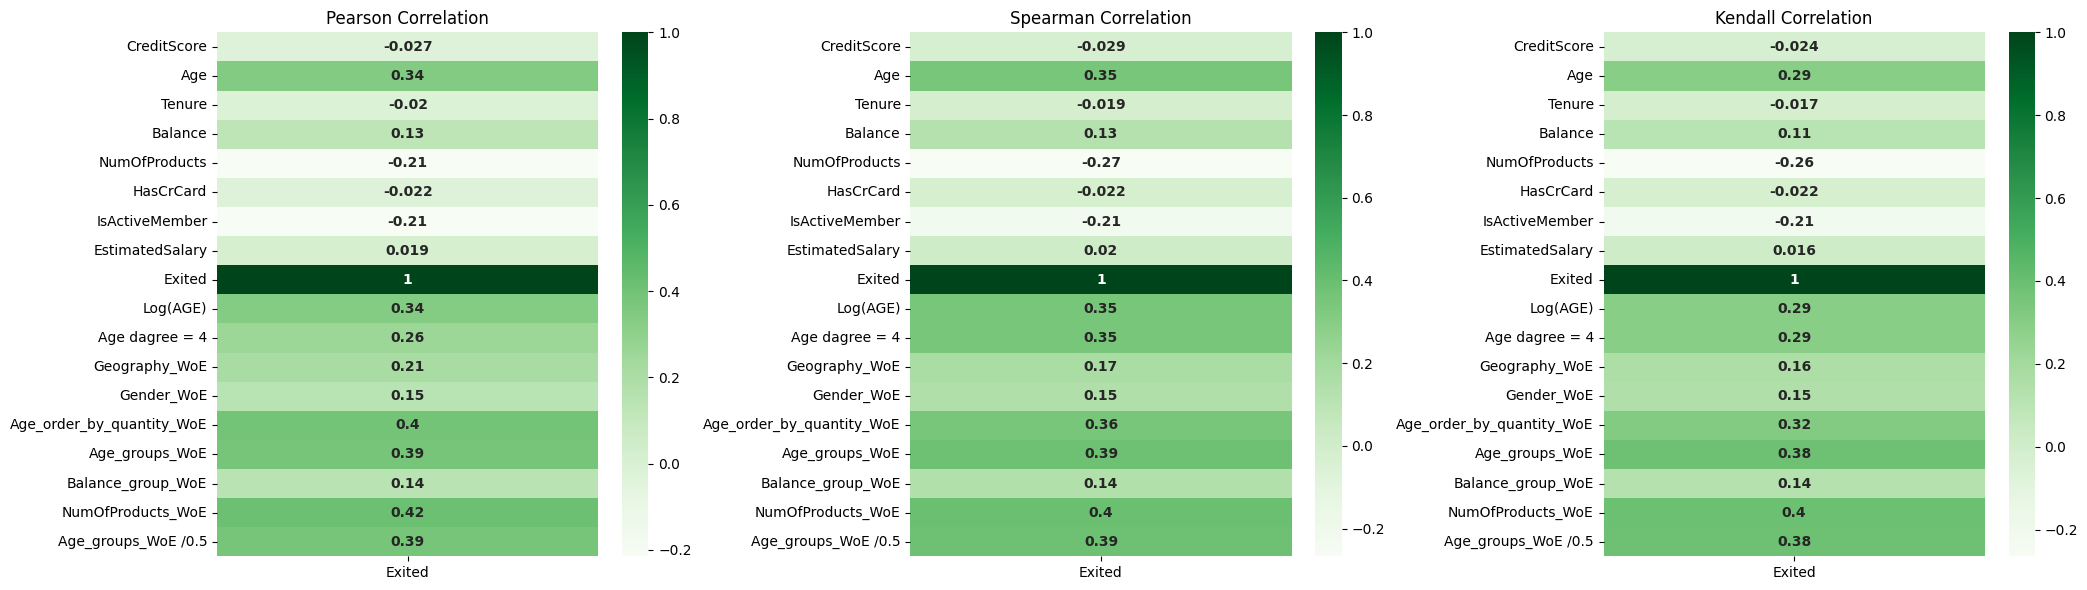

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.heatmap(df.select_dtypes(include=['number']).corr(method="pearson")[["Exited"]],  annot=True, annot_kws={"size": 10, "weight": 'bold'}, cmap="Greens", ax=axes[0])
axes[0].set_title('Pearson Correlation')

sns.heatmap(df.select_dtypes(include=['number']).corr(method="spearman")[["Exited"]], annot=True, annot_kws={"size": 10, "weight": 'bold'}, cmap="Greens", ax=axes[1])
axes[1].set_title('Spearman Correlation')

sns.heatmap(df.select_dtypes(include=['number']).corr(method="kendall")[["Exited"]],  annot=True, annot_kws={"size": 10, "weight": 'bold'}, cmap="Greens", ax=axes[2])
axes[2].set_title('Kendall Correlation')

plt.tight_layout()
plt.show()

In [26]:
X = df.select_dtypes(include=['number']).drop(['Exited', 'Tenure'], axis=1)
y = df['Exited']
t = 0.8885039188961106  # Bu yerda ROC-AUCning minimal qiymatini 0.005, 0.0123 0.8885262446846243

# for i in range(1, 20_000):
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty="l2" , C=0.0123))
])








In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)

pred = pipeline.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred)

0.8884219829814112

### Searching for the best hyperparameters

In [28]:
estimators = [
    ('lr_l1', LogisticRegression(penalty='l1', solver='liblinear')),
    ('lr_l2', LogisticRegression(penalty='l2')),
    ('ridge', RidgeClassifier())
]

# Define the stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(penalty='l2'),
    cv=5
)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'lr_l1__C': [9.0, 10.0, 11.0],   # Regularization for Logistic Regression with L1
    'lr_l2__C': [0.1, 1, 2],       # Regularization for Logistic Regression with L2
    'ridge__alpha': [0.1, 1, 2]    # Regularization for Ridge Classifier
}

grid_search = GridSearchCV(estimator=stacking_clf, param_grid=param_grid, scoring='roc_auc')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search.fit(X_train, y_train)

# Get the best hyperparameters and corresponding ROC AUC score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Output the results
print("Best Hyperparameters:", best_params)
print("Best ROC AUC Score:", best_score)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
test_score = roc_auc_score(y_test, best_model.predict(X_test))
print("Test ROC AUC Score:", test_score)

Best Hyperparameters: {'lr_l1__C': 9.0, 'lr_l2__C': 2, 'ridge__alpha': 1}
Best ROC AUC Score: 0.8767397487965244
Test ROC AUC Score: 0.7443476813447153


In [29]:
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Applying all to the test data

In [ ]:
test = pd.read_csv("test.csv", index_col=0).drop(["Surname", "CustomerId"], axis=1)
featuer_engineering(test)
featuer_engineering_woe(test)
test["Age_groups_WoE /0.5"] = test["Age_groups_WoE"] // 0.5


sub = pd.read_csv("submission.csv", index_col=0)
sub["Exited"] = pipeline.predict_proba(test.select_dtypes(include=['number']).drop(['Tenure'], axis=1))[:,1]


sub.to_csv("sub.csv")